In [1]:
cd "/storage/home/hcoda1/9/pagrawala6/r-js130-0/thesisplots/"

/storage/project/r-js130-0/pagrawala6/thesisplots


In [2]:
import duckdb

# Connect to the DuckDB database file
duo_conn = duckdb.connect("duo_oxygen1616_schumannrunge_finalrun.duckdb")

# Execute the query to show all tables and fetch the result as a DataFrame
table_names = duo_conn.execute("SHOW TABLES;").fetchdf()

# Print the resulting DataFrame
print(table_names)
duo_conn = duckdb.connect("duo_oxygen1616_schumannrunge_finalrun.duckdb")
(duo_conn.execute("DESCRIBE duo_oxygen1616_schumannrunge").df())
df = duo_conn.execute("SELECT * FROM duo_oxygen1616_schumannrunge LIMIT 5").df()
df


                           name
0  duo_oxygen1616_schumannrunge
1               sum_over_states


,idx,line_pos,A,Strength,up_el,up_v,up_J,up_lambda,up_sigma,up_omega,up_energy,down_el,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,Intensity
0,0,54659.5127,1026.800940,0.000060,B3Sigma-,9,1.0,0.0,-1.0,-1.0,54662.3866,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8739,1.926987e-22
1,1,55105.0711,1499.359150,0.000086,B3Sigma-,10,1.0,0.0,-1.0,-1.0,55107.9450,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8739,2.768513e-22
2,2,57037.8441,1363.856470,0.000070,B3Sigma-,18,1.0,0.0,-1.0,-1.0,57040.7180,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8739,2.350533e-22
3,3,53142.8856,182.005088,0.000012,B3Sigma-,6,1.0,0.0,-1.0,-1.0,53145.7595,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8739,3.613410e-23
4,4,56630.1915,3459.316510,0.000182,B3Sigma-,15,1.0,0.0,-1.0,-1.0,56633.0654,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8739,6.048089e-22


In [3]:
conn = duckdb.connect("hitran_oxygen1616_schumannrunge.duckdb")
conn.execute("SELECT * FROM hitran_transitions_schumann_runge LIMIT 5").df()
duo_conn.execute("SELECT * FROM duo_oxygen1616_schumannrunge LIMIT 5").df()
(conn.execute("DESCRIBE hitran_transitions_schumann_runge").df())
import pandas as pd

# ---------------------------------------------------------------------------
# 2) Helper: fetch one transition from a given connection / table
def fetch_row(conn, table, up_el, up_v, up_J, dn_el, dn_v, dn_J):

    if table== "hitran_transitions_schumann_runge":
        q = f"""
            SELECT
                line_pos      AS pos,
                A        AS Acoef,
                Strength      AS S,
                e_lower       AS e_low
            FROM {table}
            WHERE up_el   = '{up_el}'
            AND up_v    = {up_v}
            AND ABS(up_J  - {up_J})  < 1e-6     -- float-safe match
            AND down_el = '{dn_el}'
            AND down_v  = {dn_v}
            AND ABS(down_J- {dn_J}) < 1e-6
            LIMIT 1
        """
        return conn.execute(q).fetchdf()  # returns 0- or 1-row DataFrame
    elif table == "duo_oxygen1616_schumannrunge":
        q = f"""
            SELECT
                line_pos      AS pos,
                A         AS Acoef,
                Strength      AS S,
                down_energy       AS e_low
            FROM {table}
            WHERE up_el   = '{up_el}'
            AND up_v    = {up_v}
            AND ABS(up_J  - {up_J})  < 1e-6     -- float-safe match
            AND down_el = '{dn_el}'
            AND down_v  = {dn_v}
            AND ABS(down_J- {dn_J}) < 1e-6
            LIMIT 1
        """
        return conn.execute(q).fetchdf()
    
    else:
        raise ValueError(f"Unknown table: {table}. Please use 'hitran_transitions_schumann_runge' or 'duo_oxygen1616_schumannrunge'.")

# ---------------------------------------------------------------------------
# 3) Assemble comparison rows
def get_transitions(transitions):
    records = []

    for (up, dn) in transitions:
        up_el,  up_v,  up_J  = up
        dn_el,  dn_v,  dn_J  = dn

        hit = fetch_row(conn,     "hitran_transitions_schumann_runge",
                        up_el, up_v, up_J, dn_el, dn_v, dn_J)
        duo = fetch_row(duo_conn, "duo_oxygen1616_schumannrunge",
                        up_el, up_v, up_J, dn_el, dn_v, dn_J)

        if hit.empty or duo.empty:
            print(f"⚠️  Transition {up}->{dn} not found in "
                f"{'either database:'    if duo.empty and hit.empty else ''} "
                f"{'HITRAN' if hit.empty else ''} "
                f"{'DUO'    if duo.empty else ''}")
            continue
        # now we wish to raise an error if duo returns more than 1 row
        if len(duo) > 1:
            print (f"⚠️ Warning DUO returned more than 1 row for transition {up}->{dn}")
            continue

        if len(hit) > 1:
            print (f"⚠️ Warning HITRAN returned more than 1 row for transition {up}->{dn}")
            continue
        
        records.append({
            "up_state"      : f"{up_el} v={up_v} J={up_J}",
            "down_state"    : f"{dn_el} v={dn_v} J={dn_J}",
            "pos_duo"       : duo.at[0, "pos"],
            "pos_HITRAN"    : hit.at[0, "pos"],
            "A_duo"         : duo.at[0, "Acoef"],
            "A_HITRAN"      : hit.at[0, "Acoef"],
            "S_duo"         : duo.at[0, "S"],
            "S_HITRAN"      : hit.at[0, "S"],
            "e_low_duo"     : duo.at[0, "e_low"],
            "e_low_HITRAN"  : hit.at[0, "e_low"],
        })

    return records



In [4]:
# print number of transitions in each database
# fix TypeError: object of type 'int' has no len()
print("Number of transitions in HITRAN:", (conn.execute("SELECT COUNT(*) FROM hitran_transitions_schumann_runge").fetchone()[0]))
print("Number of transitions in DUO:", (duo_conn.execute("SELECT COUNT(*) FROM duo_oxygen1616_schumannrunge").fetchone()[0]))
# now print max vibrational level in duo_conn   
print("Max vibrational level in DUO:", (duo_conn.execute("SELECT MAX(up_v) FROM duo_oxygen1616_schumannrunge").fetchone()[0]))



Number of transitions in HITRAN: 8920
Number of transitions in DUO: 1349502
Max vibrational level in DUO: 44


In [5]:
# ---------------------------------------------------------------------------
# 1) SUPPLIED transition list based on quantum numbers

transitions = [ 
    #    up_el    up_v  up_J   | down_el  down_v  down_J
    # sample B(0,1)       →      X(0,0)
    (('B3Sigma-',  0, 3.0), ('X3Sigma-', 2, 2.0)),   
    (('B3Sigma-',  0, 1.0), ('X3Sigma-', 4, 1)),
    (('B3Sigma-',  1, 2.0), ('X3Sigma-', 1, 1)),
    (('B3Sigma-',  7, 2.0), ('X3Sigma-', 1, 1)),
    (('B3Sigma-',  7, 3.0), ('X3Sigma-', 2, 4)),
    (('B3Sigma-',  8, 2.0), ('X3Sigma-', 1, 1)),
    (('B3Sigma-',  10, 2.0), ('X3Sigma-', 1, 1)),
    (('B3Sigma-',  13, 2.0), ('X3Sigma-', 1, 1)),
    (('B3Sigma-',  6, 29), ('X3Sigma-', 1, 30)),
    (('B3Sigma-',  9, 15.0), ('X3Sigma-', 0, 14)),
    # … add more here …
]



# ---------------------------------------------------------------------------
stored_records = get_transitions(transitions)
# 4) Present results
df_compare = pd.DataFrame.from_records(stored_records)
pd.set_option("display.float_format", "{:,.6g}".format)  # nicer numbers
display(df_compare)  # Jupyter-friendly; else use print(df_compare)





⚠️  Transition ('B3Sigma-', 0, 1.0)->('X3Sigma-', 4, 1) not found in  HITRAN 


,up_state,down_state,pos_duo,pos_HITRAN,A_duo,A_HITRAN,S_duo,S_HITRAN,e_low_duo,e_low_HITRAN
0,B3Sigma- v=0 J=3.0,X3Sigma- v=2 J=2.0,"46,317.2","46,268.7",31.7179,20.45,7.12479e-06,2.283e-28,"3,089.12","3,104.98"
1,B3Sigma- v=1 J=2.0,X3Sigma- v=1 J=1,"48,521.1","48,491.1",19.9271,19.36,2.78112e-06,2.562e-25,"1,559.46","1,560.32"
2,B3Sigma- v=7 J=2.0,X3Sigma- v=1 J=1,"52,133.3","52,100.9","14,413.1","13,620",0.00162174,1.562e-22,"1,559.46","1,560.32"
3,B3Sigma- v=7 J=3.0,X3Sigma- v=2 J=4,"50,599.4","50,539",166.794,"132,900",2.87369e-05,1.099e-24,"3,103.16","3,130.37"
4,B3Sigma- v=8 J=2.0,X3Sigma- v=1 J=1,"52,625.3","52,601","22,275.6","23,890",0.00243677,2.687e-22,"1,559.46","1,560.32"
5,B3Sigma- v=10 J=2.0,X3Sigma- v=1 J=1,"53,552.3","53,495.7","46,898.7","48,840",0.0048685,5.312e-22,"1,559.46","1,560.32"
6,B3Sigma- v=13 J=2.0,X3Sigma- v=1 J=1,"54,571.7","54,529.3","69,498.8","77,640",0.00681778,8.125e-22,"1,559.46","1,560.32"
7,B3Sigma- v=6 J=29,X3Sigma- v=1 J=30,"50,938.8","50,825.1","10,981.5","11,850",0.0156303,1.851e-24,"2,788.67","2,962.07"
8,B3Sigma- v=9 J=15.0,X3Sigma- v=0 J=14,"54,538.8","54,413.6","4,182.82",0.02159,0.00254866,5.199e-25,261.366,344.027


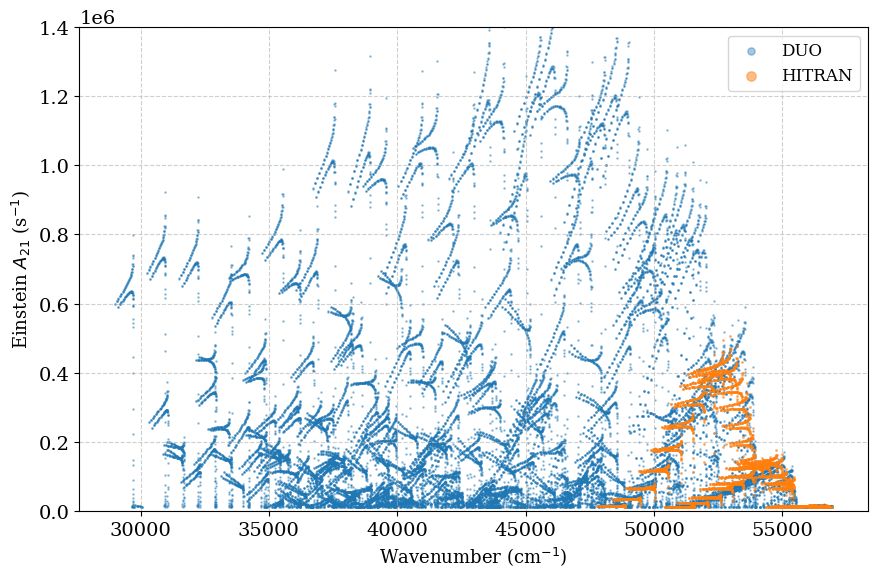

In [109]:
# % we wish to do a quick bird's eye view type plot of the whole band, to see how the A coefficients compare across the board, NOT just a single band and then we lead the discussion into the 12-2 band. Obviously we do not need HITRAN but can retain it to show comparison points.

import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
# ───────────────────────────────────────────────────────────────
# 1) Pull spectra for the chosen band
#    (up_el = B3Σ–, v′ = 10 → X3Σ–, v″ = 0  in your example)
# ───────────────────────────────────────────────────────────────
df_hitran = conn.execute("""

    SELECT line_pos AS wavenumber_cm1, A AS Acoef, up_J AS up_J, down_J AS down_J
    FROM hitran_transitions_schumann_runge
    WHERE up_el  = 'B3Sigma-' and down_J < 40 and Acoef > 10000  and down_v< 15
      AND down_el = 'X3Sigma-'
""").fetchdf()

df_duo = duo_conn.execute("""
    SELECT line_pos AS wavenumber_cm1, A AS Acoef, up_J AS up_J, down_J AS down_J
    FROM duo_oxygen1616_schumannrunge
    WHERE up_el  = 'B3Sigma-' and down_v < 15 and down_J < 40 and up_v < 20
      AND down_el = 'X3Sigma-' and Acoef > 10000
""").fetchdf()

# ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# Apply LaTeX-style serif font and base font size
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "svg.fonttype": 'none',
    # "text.usetex": True  # Uncomment for true LaTeX rendering if installed
})

plt.figure(figsize=(9, 6))

# Plot DUO: tiny dots, very low alpha, pushed to background (zorder=1)
plt.scatter(df_duo['wavenumber_cm1'], df_duo['Acoef'],
            s=3, marker='.', label='DUO', alpha=0.4, color='tab:blue', zorder=1)

# Plot HITRAN: slightly larger, higher alpha, pulled to foreground (zorder=2)
plt.scatter(df_hitran['wavenumber_cm1'], df_hitran['Acoef'],
            s=5, marker='.', label='HITRAN', alpha=0.5, color='tab:orange', zorder=2)

# Increased label size slightly (13) while keeping tick labels at the base size (11)
plt.xlabel('Wavenumber (cm$^{-1}$)', fontsize=13)
plt.ylabel('Einstein $A_{21}$ (s$^{-1}$)', fontsize=13)

# Adding markerscale to legend so the legend dots are visible
plt.legend(markerscale=6, fontsize=12) 
plt.ylim(0, 1.4e6)  # Adjust as needed to focus on the most relevant range of A coefficients
plt.grid(True, ls='--', alpha=0.6)
plt.tight_layout()
plt.savefig('disc_1.svg', format='svg', bbox_inches='tight')
plt.show()
# remember to save it as a RASTERIZED svg so the points do not crash the vector graphics viewer

In [108]:
ls -lh

total 989M
-rw-r--r--. 1 pagrawala6 pace-js130 888K Mar 21 07:26 0_beginning.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 661K Mar 21 13:18 1_discretebands.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 550K Mar 21 08:57 2_cont_preanalysis.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 994K Mar 21 09:23 3_cont_spectraanalysis.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 215K Mar 20 23:55 4_discretepol.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 2.0M Mar 21 09:02 5_mainpolanalysis.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130  71K Mar 21 09:20 PEC_wavefunction_overlap_schematic.pdf
-rw-r--r--. 1 pagrawala6 pace-js130 184K Mar 21 09:20 PEC_wavefunction_overlap_v2.pdf
-rw-r--r--. 1 pagrawala6 pace-js130 136K Mar 19 04:16 Z_Einstein_A_J_dependence.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 245K Mar 19 04:16 Z_X_to_E_proof.ipynb
-rw-r--r--. 1 pagrawala6 pace-js130 956K Mar 21 06:06 band_origin_comparison.jpeg
-rw-r--r--. 1 pagrawala6 pace-js130  22K Mar 21 09:19 cont_vib_levels_and_widths.pdf
-rw-r--r--. 1 pagraw

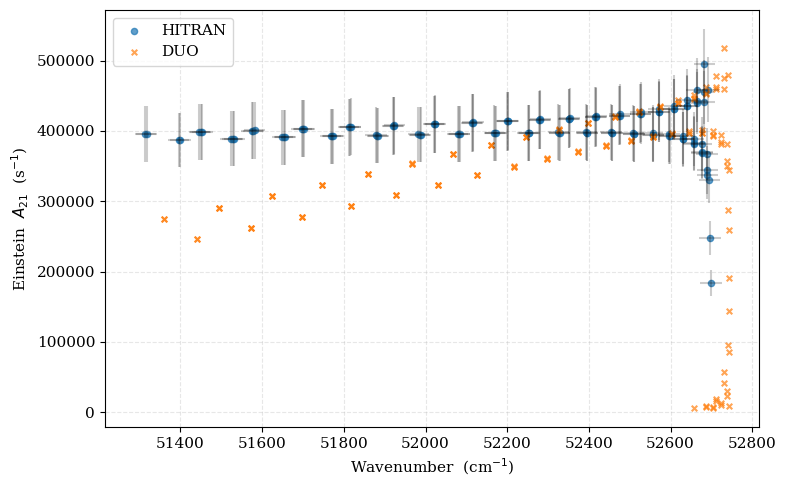

In [101]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
# ───────────────────────────────────────────────────────────────
# 1) Pull spectra for the chosen band
#    (up_el = B3Σ–, v′ = 10 → X3Σ–, v″ = 0  in your example)
# ───────────────────────────────────────────────────────────────
df_hitran = conn.execute("""

    SELECT line_pos AS wavenumber_cm1, A AS Acoef, up_J AS up_J, down_J AS down_J
    FROM hitran_transitions_schumann_runge
    WHERE up_el  = 'B3Sigma-' AND up_v  = 12
      AND down_el = 'X3Sigma-' AND down_v = 2 and down_J < 40 and Acoef > 5000
""").fetchdf()

df_duo = duo_conn.execute("""
    SELECT line_pos AS wavenumber_cm1, A AS Acoef, up_J AS up_J, down_J AS down_J
    FROM duo_oxygen1616_schumannrunge
    WHERE up_el  = 'B3Sigma-' AND up_v  = 12
      AND down_el = 'X3Sigma-' AND down_v = 2 and down_J < 40 and Acoef > 5000
""").fetchdf()

# ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    # "text.usetex": True  # Uncomment for true LaTeX rendering if installed
})
plt.scatter(df_hitran['wavenumber_cm1'], df_hitran['Acoef'],
            s=20, marker='o', label='HITRAN', alpha=0.7)
# add plus or minus 10% error bars to hitran
plt.errorbar(df_hitran['wavenumber_cm1'], df_hitran['Acoef'],
             yerr=df_hitran['Acoef']*0.1, xerr= df_hitran['wavenumber_cm1']*0.0005, fmt='none', ecolor='black', alpha=0.2)

plt.scatter(df_duo['wavenumber_cm1'], df_duo['Acoef'],
            s=16, marker='x', label='DUO', alpha=0.7)
# plt.ylim(0, 1000000)  # Adjust y-limits as needed
plt.xlabel('Wavenumber  (cm$^{-1}$)')
plt.ylabel('Einstein  $A_{21}$  (s$^{-1}$)')
# plt.xlim(54700, 55200)  # Adjust as needed for your band
# plt.title(r"B$^{3}\Sigma^{-}$ $\,v'=12\!\rightarrow\!$ X$^{3}\Sigma^{-}$ $\,v''=1$  band")
plt.legend()
plt.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.savefig('disc_2.svg', format='svg', bbox_inches='tight')
plt.show()

In [7]:
# we wish to do a plot like previous but we want to plot the error in Einstein A on the Y axis, and log Einstein A on the X . what this does is show the relative error in A as a function of A, which is more meaningful than absolute error since A can vary over many orders of magnitude. we can also add error bars to the hitran points to show the uncertainty in A. let's do that next.


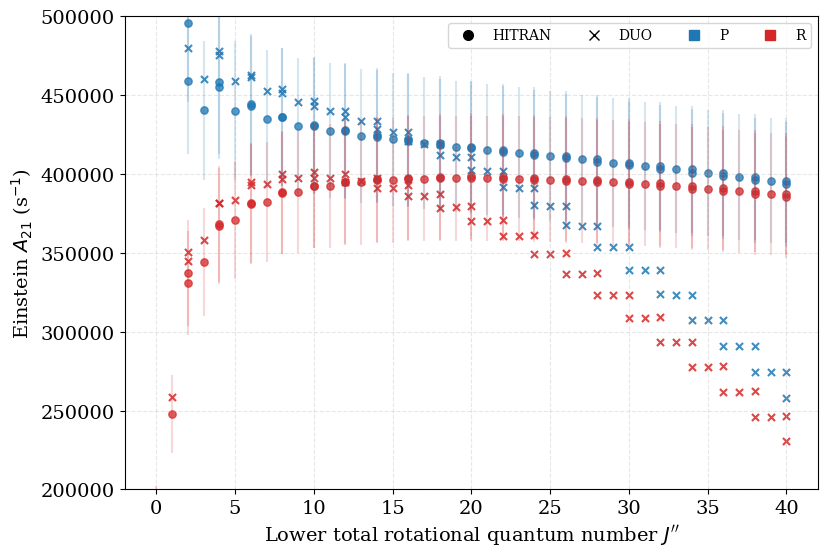

In [110]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
%matplotlib inline

# ───────────────────────────────────────────────────────────────
# 1) Pull spectra for the chosen band
#    (up_el = B3Sigma-, v' = 12 -> X3Sigma-, v'' = 2 in this example)
# ───────────────────────────────────────────────────────────────
df_hitran = conn.execute("""
    SELECT line_pos AS wavenumber_cm1, A AS Acoef, up_J AS up_J, down_J AS down_J
    FROM hitran_transitions_schumann_runge
    WHERE up_el  = 'B3Sigma-' AND up_v  = 12
      AND down_el = 'X3Sigma-' AND down_v = 2 AND down_J < 41 AND A > 10000
""").fetchdf()

df_duo = duo_conn.execute("""
    SELECT line_pos AS wavenumber_cm1, A AS Acoef, up_J AS up_J, down_J AS down_J
    FROM duo_oxygen1616_schumannrunge
    WHERE up_el  = 'B3Sigma-' AND up_v  = 12
      AND down_el = 'X3Sigma-' AND down_v = 2 AND down_J < 41 AND A > 10000
""").fetchdf()

# Branch definition using Delta J = J' - J''
df_hitran["delta_J"] = df_hitran["up_J"] - df_hitran["down_J"]
df_duo["delta_J"] = df_duo["up_J"] - df_duo["down_J"]

branch_specs = [
    ("P", -1, "tab:blue"),
    ("R", 1, "tab:red"),
]

# ───────────────────────────────────────────────────────────────
# 2) Single plot with branch colors
# ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.5, 5.8))

for branch_name, dJ, color in branch_specs:
    hit = df_hitran[np.isclose(df_hitran["delta_J"], dJ)]
    duo = df_duo[np.isclose(df_duo["delta_J"], dJ)]
    hit = hit.sort_values("down_J")
    duo = duo.sort_values("down_J")
    ax.scatter(
        hit["down_J"], hit["Acoef"],
        s=28, marker="o", color=color, alpha=0.75
    )

    ax.errorbar(
        hit["down_J"], hit["Acoef"],
        yerr=hit["Acoef"] * 0.1,
        fmt="none", ecolor=color, alpha=0.18
    )

    ax.scatter(
        duo["down_J"], duo["Acoef"],
        s=26, marker="x", color=color, alpha=0.85
    )

ax.set_xlabel(r"Lower total rotational quantum number $J''$")
ax.set_ylim(200000, 500000)  # Adjust as needed to focus on the most relevant range of A coefficients
ax.set_ylabel(r"Einstein $A_{21}$ (s$^{-1}$)")
# ax.set_title(r"B$^{3}\Sigma^{-}$ $\,v'=12\!\rightarrow\!$ X$^{3}\Sigma^{-}$ $\,v''=2$ (P/R vs $J''$)")
ax.grid(True, ls="--", alpha=0.3)
# % remove q branch entirely
# Compact legend: marker style for database + color for branch.
legend_handles = [
    Line2D([0], [0], marker='o', color='k', linestyle='None', markersize=7, label='HITRAN'),
    Line2D([0], [0], marker='x', color='k', linestyle='None', markersize=7, label='DUO'),
    Line2D([0], [0], marker='s', color='tab:blue', linestyle='None', markersize=7, label='P'),
    Line2D([0], [0], marker='s', color='tab:red', linestyle='None', markersize=7, label='R'),
]
ax.legend(handles=legend_handles, ncol=5, loc='upper right', frameon=True, fontsize=10)
plt.savefig('disc_3.svg', format='svg', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
# $ since we have established that HITRAN's dependence on the franck condon factor is responsible fo r this deviation, we now plot band origins 

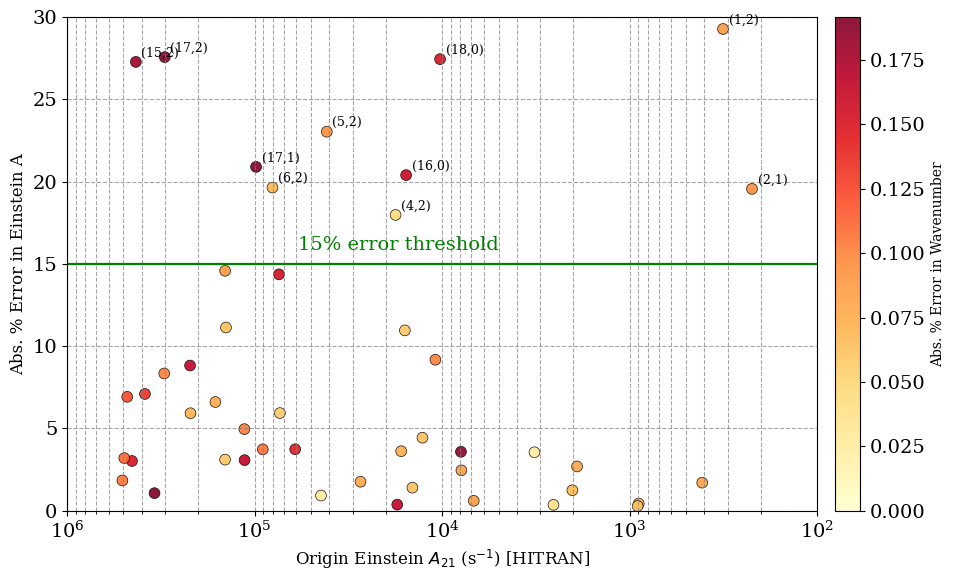

Top 15 Bands by Einstein A Error:


,up_v,down_v,up_J,down_J,A_hit,abs_pct_err_A,abs_pct_err_wn
3,3,2,1,0,225,624.562,0.0539238
0,1,2,1,2,318.3,29.2719,0.0892987
44,17,2,1,2,"301,200",27.563,0.205793
45,18,0,1,2,"10,260",27.4383,0.151238
38,15,2,1,2,"429,600",27.2706,0.179593
8,5,2,1,2,"41,220",23.0275,0.0934493
43,17,1,1,2,"98,190",20.8906,0.194892
39,16,0,1,2,"15,570",20.3911,0.161676
11,6,2,1,2,"80,280",19.6336,0.0703818
1,2,1,1,2,223,19.5549,0.0957836


Number of vibrational bands compared: 48
Number of unique (v', v'') pairs: 48


In [111]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

# 1) Define the full range of vibrational bands to compare
bands_to_compare = [(v_up, v_lo) for v_up in range(0, 25) for v_lo in range(0, 25)]
bands_to_compare = [(v_up, v_lo) for v_up, v_lo in bands_to_compare if v_up != 19]
bands_to_compare = [(v_up, v_lo) for v_up, v_lo in bands_to_compare if not (v_up == 2 and v_lo == 2)]

# 2) Data extraction focusing ONLY on the band origin proxy (Lowest J)
def get_band_origins(band_list):
    all_data = []
    
    for u_v, d_v in band_list:
        q_hit = f"""
            SELECT up_v, down_v, up_J, down_J, line_pos AS pos_hit, A AS A_hit
            FROM hitran_transitions_schumann_runge
            WHERE up_el='B3Sigma-' AND up_v={u_v} AND down_el='X3Sigma-' 
              AND down_v={d_v} AND A > 200 AND down_J <= 8
        """
        df_h = conn.execute(q_hit).fetchdf()
        
        q_duo = f"""
            SELECT up_v, down_v, up_J, down_J, line_pos AS pos_duo, A AS A_duo
            FROM duo_oxygen1616_schumannrunge
            WHERE up_el='B3Sigma-' AND up_v={u_v} AND down_el='X3Sigma-' 
              AND down_v={d_v} AND A > 200 AND down_J <= 8
        """
        df_d = duo_conn.execute(q_duo).fetchdf()
        
        if not df_h.empty and not df_d.empty:
            merged = pd.merge(df_h, df_d, on=["up_v", "down_v", "up_J", "down_J"], how="inner")
            
            if not merged.empty:
                merged["temp_err"] = np.abs((merged["A_duo"] - merged["A_hit"]) / merged["A_hit"])
                merged = merged.sort_values(by=["up_J", "temp_err"], ascending=[True, True])
                all_data.append(merged.head(1))
    
    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

# 3) Acquire and Process
df_origins = get_band_origins(bands_to_compare)

if not df_origins.empty:
    df_origins["abs_pct_err_A"]  = df_origins["temp_err"] * 100
    df_origins["abs_pct_err_wn"] = np.abs((df_origins["pos_duo"] - df_origins["pos_hit"]) / df_origins["pos_hit"]) * 100

    err_A  = df_origins["abs_pct_err_A"]
    err_wn = df_origins["abs_pct_err_wn"]

    # ─── Plot ───
    fig, ax1 = plt.subplots(figsize=(10, 6))

    sc = ax1.scatter(
        df_origins["A_hit"], err_A,
        c=err_wn, cmap="YlOrRd", norm=plt.Normalize(vmin=0, vmax=err_wn.quantile(0.95)),
        s=60 + 4 * err_wn,
        edgecolors="black", linewidths=0.5, alpha=0.9
    )
    cbar = plt.colorbar(sc, ax=ax1, pad=0.02)
    cbar.set_label("Abs. % Error in Wavenumber", fontsize=10)

    # Annotate outliers only
    for _, row in df_origins[df_origins["abs_pct_err_A"] > 15].iterrows():
        ax1.annotate(
            f"({int(row['up_v'])},{int(row['down_v'])})",
            xy=(row["A_hit"], row["abs_pct_err_A"]),
            fontsize=9, color="black",
            xytext=(4, 4), textcoords="offset points"
        )
    # annotate also the 15% y line and label it as "15% error threshold"
    ax1.axhline(15, color="green", linestyle="-", linewidth=1.6, alpha=1)
    ax1.annotate("15% error threshold", xy=(0.7e5, 15), xytext=(10, 10),
                textcoords="offset points", fontsize=14, color="green")

    ax1.set_xscale("log")
    ax1.set_xlim(1e2, 1e6)
    ax1.invert_xaxis()
    ax1.set_xlabel(r"Origin Einstein $A_{21}$ (s$^{-1}$) [HITRAN]", fontsize=12)
    ax1.set_ylabel("Abs. % Error in Einstein A", fontsize=12)
    ax1.set_ylim(0, 30)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.8, alpha=0.7, color="gray")
    plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    # "text.usetex": True  # Uncomment for true LaTeX rendering if installed
})
    # plt.title("Schumann-Runge Band Origin Comparison: DUO vs. HITRAN", fontsize=14)
    plt.tight_layout()
    plt.savefig("disc_4origin_comparison.svg", format="svg", bbox_inches="tight")
    plt.show()

    # ─── Summary ───
    print("Top 15 Bands by Einstein A Error:")
    display(df_origins[["up_v", "down_v", "up_J", "down_J", "A_hit", "abs_pct_err_A", "abs_pct_err_wn"]]
            .sort_values("abs_pct_err_A", ascending=False).head(15))

else:
    print("No matching transitions found for the specified band origins.")

num_bands = df_origins.shape[0]
num_unique_bands = df_origins[["up_v", "down_v"]].drop_duplicates().shape[0]
print(f"Number of vibrational bands compared: {num_bands}")
print(f"Number of unique (v', v'') pairs: {num_unique_bands}")


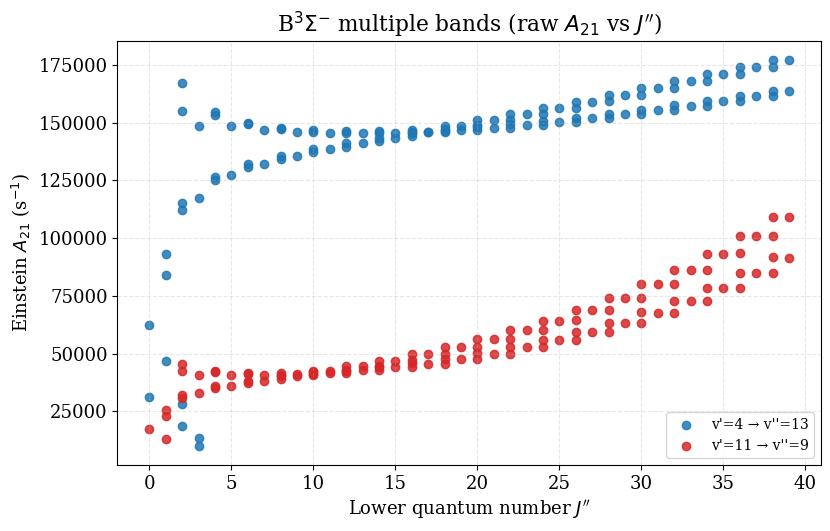

In [113]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ──────────────────────────────────────────────
# 1) Define the bands you want to plot (up_v, down_v)
# ──────────────────────────────────────────────
bands = [
    (4, 13),
    (11, 9),
]

# Colors for each band
colors = ["tab:blue", "tab:red", "tab:green"]

fig, ax = plt.subplots(figsize=(8.5, 5.5))

for (up_v, down_v), color in zip(bands, colors):
    # Fetch data for this band
    df_band = duo_conn.execute(f"""
        SELECT line_pos AS wavenumber_cm1, A AS Acoef, up_J AS up_J, down_J AS down_J
        FROM duo_oxygen1616_schumannrunge
        WHERE up_el  = 'B3Sigma-' AND up_v  = {up_v}
          AND down_el = 'X3Sigma-' AND down_v = {down_v} AND down_J < 40 AND A > 10000
    """).fetchdf()
    
    # Sort by lower J for better plotting
    df_band = df_band.sort_values("down_J")
    
    # Plot raw A values
    ax.scatter(df_band["down_J"], df_band["Acoef"], s=36, marker="o", color=color, alpha=0.85,
               label=f"v'={up_v} → v''={down_v}")

ax.set_xlabel(r"Lower quantum number $J''$")
ax.set_ylabel(r"Einstein $A_{21}$ (s$^{-1}$)")
ax.set_title(r"B$^{3}\Sigma^{-}$ multiple bands (raw $A_{21}$ vs $J''$)")
ax.grid(True, ls="--", alpha=0.3)

# Legend for all bands
ax.legend(frameon=True, fontsize=10)
plt.savefig('disc_5.svg', format='svg', bbox_inches='tight')
plt.tight_layout()
plt.show()

# % change to log plot for coupleaanomolies